# Bayesian Neural Network

### Introduction

This notebook demonstrates Bayesian models for binary classification, progressing from Bayesian Logistic Regression to Bayesian Neural Networks, and then to BNNs with rich feature types: **categorical embeddings** or **numerical normalization**.

The notebook is based on the example in https://num.pyro.ai/en/latest/tutorials/bayesian_regression.html

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

from pybandits.model import (
    BayesianNeuralNetwork,
    CategoricalFeatureConfig,
    FeaturesConfig,
)

rng = np.random.default_rng(seed=0)

%load_ext autoreload
%autoreload 2

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_map(value, grid, x_test, pred, metric, title=""):
    cmap = plt.get_cmap("coolwarm")
    fig, ax = plt.subplots(figsize=(10, 6))
    contour = ax.contourf(*grid, value.reshape(100, 100), cmap=cmap)
    ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1], label="Class 0")
    ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color="r", label="Class 1")
    cbar = plt.colorbar(contour, ax=ax)
    cbar.ax.set_ylabel(f"{metric} of Output")
    ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="X1", ylabel="X2", title=title or metric)
    ax.legend()
    plt.show()

## Generate Data

We generate a 2-D binary dataset that is not linearly separable (two interleaved moons), then split it into training and test sets. A dense 2-D grid is also created here for the uncertainty maps used throughout the notebook.

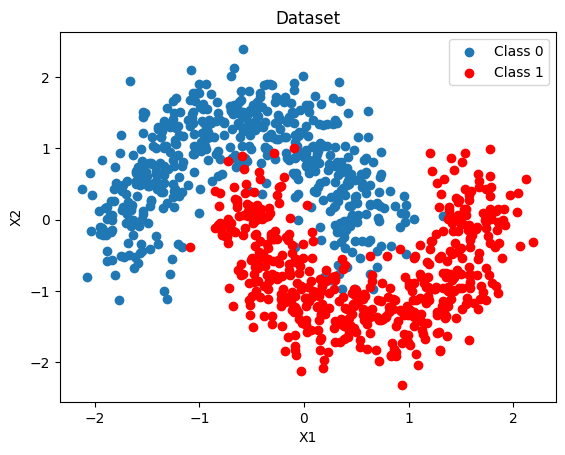

In [3]:
X, Y = make_moons(noise=0.2, random_state=0, n_samples=1000)
X = scale(X)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.5)
y_train = y_train.tolist()
y_test = y_test.tolist()

fig, ax = plt.subplots()
ax.scatter(X[Y == 0, 0], X[Y == 0, 1], label="Class 0")
ax.scatter(X[Y == 1, 0], X[Y == 1, 1], color="r", label="Class 1")
ax.set(xlabel="X1", ylabel="X2", title="Dataset")
ax.legend()

# 2-D grid for uncertainty maps — reused by every model below
grid = np.mgrid[-3:3:100j, -3:3:100j].astype(float)
grid_2d = grid.reshape(2, -1).T

## Bayesian Logistic Regression

Using `BayesianNeuralNetwork.cold_start` we create a probabilistic linear classifier with Student-T weight priors (default: mu=0, sigma=10, nu=5).

We fit it with Variational Inference using Adam and minibatches of 256.

In [4]:
blr = BayesianNeuralNetwork.cold_start(
    n_features=2,
    update_method="VI",
    update_kwargs={"num_steps": 4000, "batch_size": 256, "optimizer_type": "adam"},
)
blr.update(context=x_train, rewards=y_train)

SVI:   0%|          | 0/4000 [00:00<?, ?it/s]

SVI:   0%|          | 1/4000 [00:00<57:03,  1.17it/s]

SVI:   0%|          | 1/4000 [00:00<57:03,  1.17it/s, loss=3068.7905]

SVI:   0%|          | 2/4000 [00:00<57:02,  1.17it/s, loss=748.1384] 

SVI:   0%|          | 3/4000 [00:00<57:01,  1.17it/s, loss=4587.0601]

...

SVI: 100%|█████████▉| 3996/4000 [00:07<00:00, 607.72it/s, loss=156.5335]

SVI: 100%|█████████▉| 3997/4000 [00:07<00:00, 607.72it/s, loss=187.8333]

SVI: 100%|█████████▉| 3998/4000 [00:07<00:00, 607.72it/s, loss=170.5373]

SVI: 100%|█████████▉| 3999/4000 [00:07<00:00, 607.72it/s, loss=171.5704]

SVI: 100%|██████████| 4000/4000 [00:07<00:00, 607.72it/s, loss=165.1341]

In [5]:
batch_predictions = [blr.sample_proba(x_test, rng=rng) for _ in range(500)]
batch_proba_blr = np.array([[p[0] for p in preds] for preds in batch_predictions])
pred_proba_blr = batch_proba_blr.mean(axis=0)
pred_blr = pred_proba_blr > 0.5

accuracy_blr = accuracy_score(y_test, pred_blr)
auc_blr = roc_auc_score(y_test, pred_proba_blr)
print(f"BLR — Accuracy: {accuracy_blr:.3f}, AUC: {auc_blr:.3f}")

BLR — Accuracy: 0.870, AUC: 0.951


Because BLR is linear it struggles with the non-linear moon boundary.

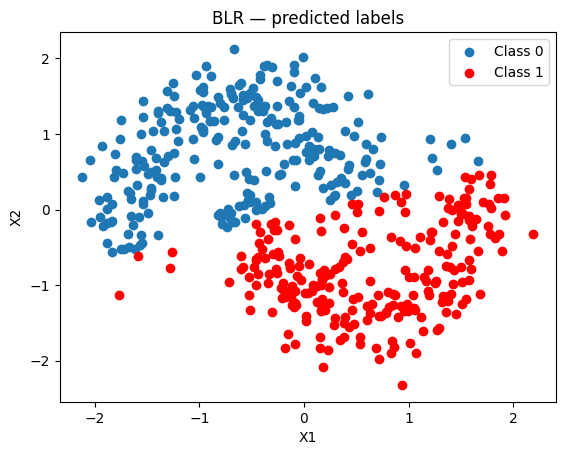

In [6]:
fig, ax = plt.subplots()
ax.scatter(x_test[pred_blr == 0, 0], x_test[pred_blr == 0, 1], label="Class 0")
ax.scatter(x_test[pred_blr == 1, 0], x_test[pred_blr == 1, 1], color="r", label="Class 1")
ax.set(title="BLR — predicted labels", xlabel="X1", ylabel="X2")
ax.legend()

We can check convergence by plotting the Evidence Lower Bound (ELBO) over iterations.
ELBO is a metric used in Variational Inference to measure the convergence of the approximation to the true posterior — a higher ELBO indicates a better approximation.
https://en.wikipedia.org/wiki/Evidence_lower_bound

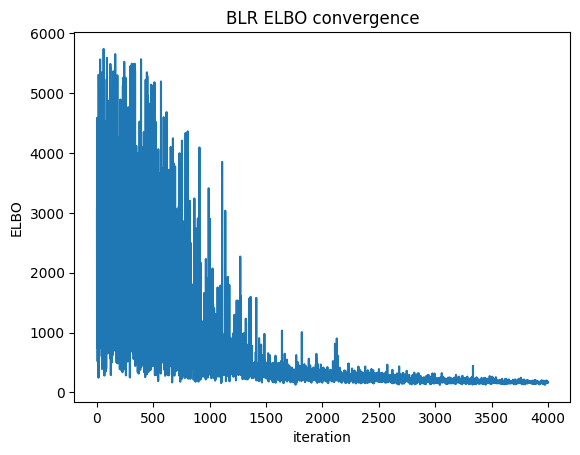

In [7]:
plt.plot(blr.approx_history)
plt.ylabel("ELBO")
plt.xlabel("iteration")
plt.title("BLR ELBO convergence")
plt.show()

### Predictions + uncertainty map

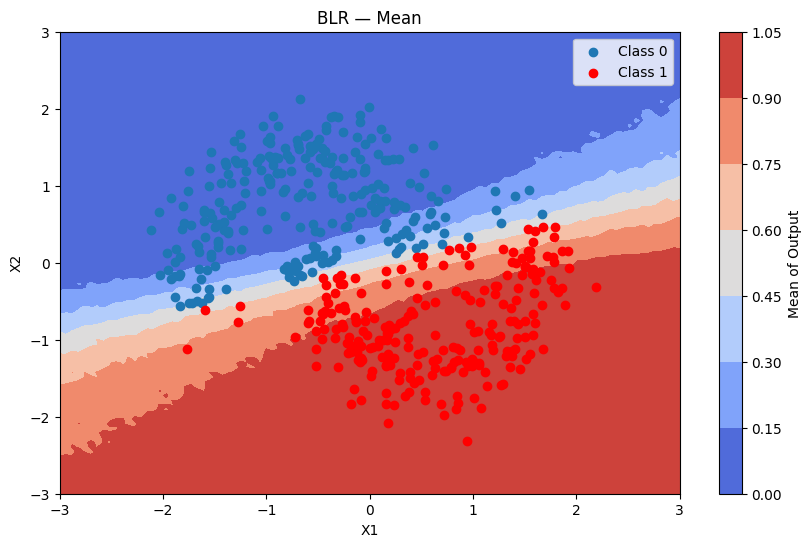

In [8]:
batch_predictions = [blr.sample_proba(grid_2d, rng=rng) for _ in range(500)]
batch_proba_blr_grid = np.array([[p[0] for p in preds] for preds in batch_predictions])

plot_map(batch_proba_blr_grid.mean(axis=0), grid, x_test, pred_blr, "Mean", "BLR — Mean")

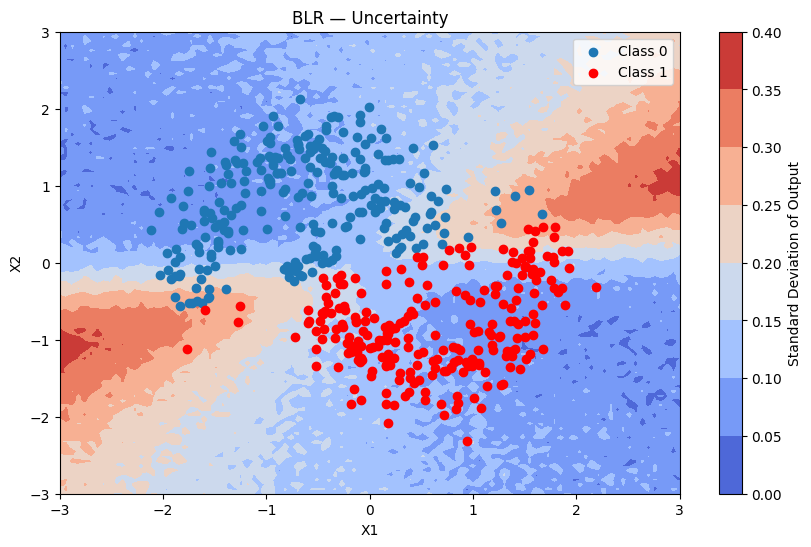

In [9]:
plot_map(batch_proba_blr_grid.std(axis=0), grid, x_test, pred_blr, "Standard Deviation", "BLR — Uncertainty")

## Bayesian Neural Network

A BNN captures non-linear decision boundaries through multiple hidden layers. Each weight is a random variable with a Student-T prior, jointly updated with VI.

Model settings:
- `hidden_dim_list=[16, 16]` — two hidden layers with 16 neurons each
- `activation="tanh"` — symmetric, works well with zero-centred priors
- `use_residual_connections=True` — skip connections improve gradient flow in deeper networks
- `dist_type="studentt"`, `dist_params_init={"mu": 0, "sigma": 1, "nu": 5}`

## Using Bayesian Neural Network

In the following section we will demonstrate how a bayesian neural network (BNN) can capture complex patterns and relationships in data through multiple layers of abstraction, leading to better performance on tasks with high-dimensional features. In contrast, bayesian logistic regression is limited to linear relationships and may not effectively model intricate dependencies within the data.

In order to define the model structure, we set:

- **Model structure**: The `hidden_dim_list=[16, 16]`, which means that the model structure will have a 2-layer network with 16 neurons in each hidden layer.
- **Activation function**: We use `activation="tanh"` for tanh activation (other options: "relu", "sigmoid", "gelu")
- **Residual connections**: We enable `use_residual_connections=True` to help with gradient flow in deeper networks

The fit is performed using the **Variational Inference** algorithm with `10K` iterations, and with minibatches of size `64`.

The neurons' **Student-t distribution** are initialized with `mu = 0, sigma = 1 and nu = 5` (Student-t is the default distribution type).


In [10]:
dist_params = {"mu": 0, "sigma": 1, "nu": 5}  # dist_type defaults to "studentt"
bnn = BayesianNeuralNetwork.cold_start(
    n_features=2,
    hidden_dim_list=[16, 16],
    activation="tanh",
    use_residual_connections=True,
    update_method="VI",
    dist_type="studentt",
    dist_params_init=dist_params,
    update_kwargs={"num_steps": 4000, "batch_size": 64, "optimizer_type": "adam"},
)

Applying the update method will calculate the approximated posterior of the parameters, and update the model. 

In [11]:
bnn.update(context=x_train, rewards=y_train)

SVI:   0%|          | 0/572 [00:00<?, ?it/s]

SVI:   0%|          | 1/572 [00:02<23:42,  2.49s/it]

SVI:   0%|          | 1/572 [00:02<23:42,  2.49s/it, loss=1550.7094]

SVI:   0%|          | 2/572 [00:02<23:40,  2.49s/it, loss=1190.5481]

SVI:   1%|          | 3/572 [00:02<23:37,  2.49s/it, loss=1176.9269]

...

SVI:  99%|█████████▉| 568/572 [00:04<00:00, 363.84it/s, loss=124.5070]

SVI:  99%|█████████▉| 569/572 [00:04<00:00, 363.84it/s, loss=134.8083]

SVI: 100%|█████████▉| 570/572 [00:04<00:00, 363.84it/s, loss=164.5744]

SVI: 100%|█████████▉| 571/572 [00:04<00:00, 363.84it/s, loss=160.2981]

SVI: 100%|██████████| 572/572 [00:06<00:00, 363.84it/s, loss=161.2351]

In [12]:
batch_predictions = [bnn.sample_proba(x_test, rng=rng) for _ in range(500)]
batch_proba_bnn = np.array([[p[0] for p in preds] for preds in batch_predictions])
pred_proba_bnn = batch_proba_bnn.mean(axis=0)
pred_bnn = pred_proba_bnn > 0.5

accuracy_bnn = accuracy_score(y_test, pred_bnn)
auc_bnn = roc_auc_score(y_test, pred_proba_bnn)
print(f"BNN — Accuracy: {accuracy_bnn:.3f}, AUC: {auc_bnn:.3f}")
print(f"BLR — Accuracy: {accuracy_blr:.3f}, AUC: {auc_blr:.3f}")

BNN — Accuracy: 0.966, AUC: 0.985
BLR — Accuracy: 0.870, AUC: 0.951


The BNN produces a much better separation than the linear BLR.

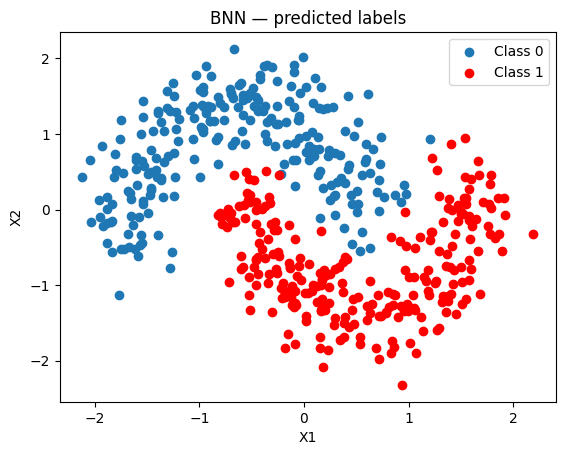

In [13]:
fig, ax = plt.subplots()
ax.scatter(x_test[pred_bnn == 0, 0], x_test[pred_bnn == 0, 1], label="Class 0")
ax.scatter(x_test[pred_bnn == 1, 0], x_test[pred_bnn == 1, 1], color="r", label="Class 1")
ax.set(title="BNN — predicted labels", xlabel="X1", ylabel="X2")
ax.legend()

ELBO convergence

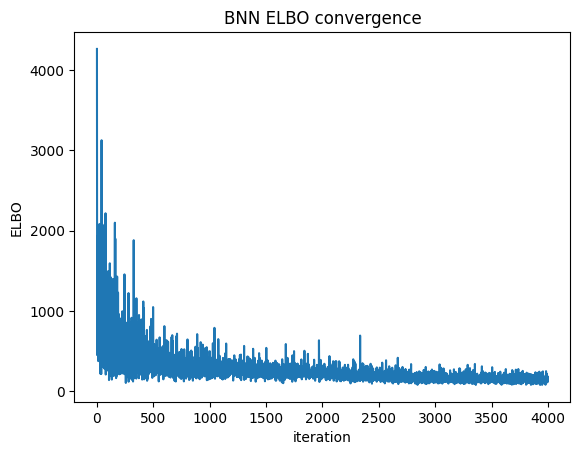

In [14]:
plt.plot(bnn.approx_history)
plt.ylabel("ELBO")
plt.xlabel("iteration")
plt.title("BNN ELBO convergence")
plt.show()

### Predictions + uncertainty map

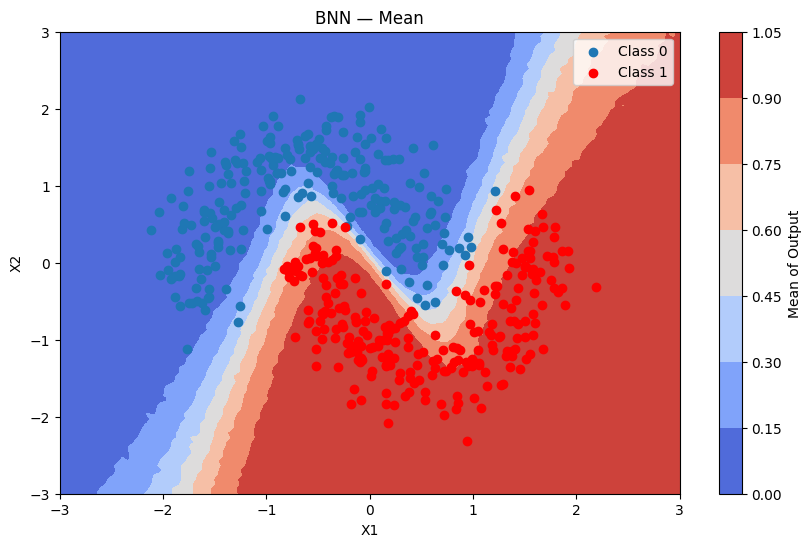

In [15]:
batch_predictions = [bnn.sample_proba(grid_2d, rng=rng) for _ in range(500)]
batch_proba_bnn_grid = np.array([[p[0] for p in preds] for preds in batch_predictions])

plot_map(batch_proba_bnn_grid.mean(axis=0), grid, x_test, pred_bnn, "Mean", "BNN — Mean")

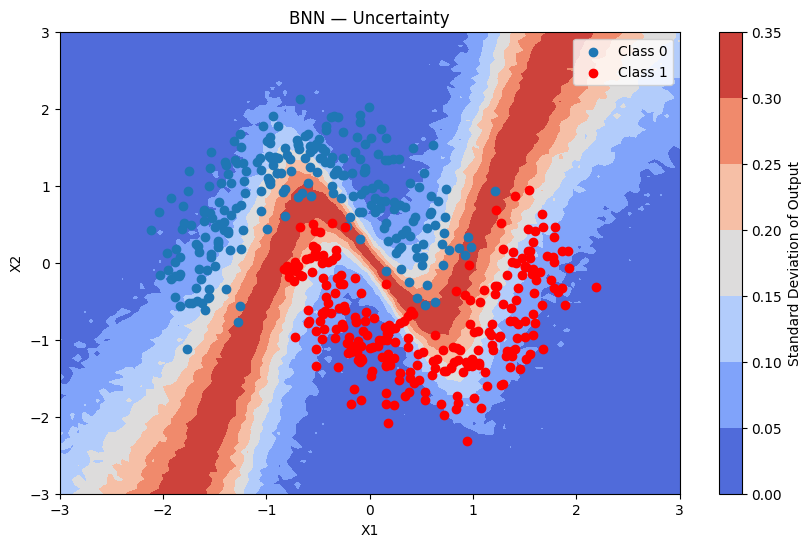

In [16]:
plot_map(batch_proba_bnn_grid.std(axis=0), grid, x_test, pred_bnn, "Standard Deviation", "BNN — Uncertainty")

### Using Normal Priors Instead of Student-t

You can replace the Student-T prior with a Normal prior by setting `dist_type="normal"` and omitting `nu` from `dist_params_init`.

| Prior | Tail weight | Robustness to outliers | Speed |
|-------|-------------|------------------------|-------|
| Student-T (default) | Heavy | High | Slightly slower |
| Normal | Light | Lower | Faster |

**When to use Normal:** faster computation, no expectation of heavy-tailed noise.
**When to use Student-T:** robustness to outliers, stronger regularisation.

In [17]:
bnn_normal = BayesianNeuralNetwork.cold_start(
    n_features=2,
    hidden_dim_list=[16, 16],
    activation="relu",
    use_residual_connections=True,
    update_method="VI",
    dist_type="normal",
    dist_params_init={"mu": 0, "sigma": 1},
    update_kwargs={"num_steps": 4000, "batch_size": 256, "optimizer_type": "adam"},
)
bnn_normal.update(context=x_train, rewards=y_train)

batch_predictions_normal = [bnn_normal.sample_proba(x_test, rng=rng) for _ in range(500)]
batch_proba_normal = np.array([[p[0] for p in preds] for preds in batch_predictions_normal])
pred_proba_normal = batch_proba_normal.mean(axis=0)
pred_normal = pred_proba_normal > 0.5

accuracy_normal = accuracy_score(y_test, pred_normal)
auc_normal = roc_auc_score(y_test, pred_proba_normal)
print(f"BNN Student-T — Accuracy: {accuracy_bnn:.3f}, AUC: {auc_bnn:.3f}")
print(f"BNN Normal    — Accuracy: {accuracy_normal:.3f}, AUC: {auc_normal:.3f}")

SVI:   0%|          | 0/4000 [00:00<?, ?it/s]

SVI:   0%|          | 1/4000 [00:01<1:47:32,  1.61s/it]

SVI:   0%|          | 1/4000 [00:01<1:47:32,  1.61s/it, loss=3956.8342]

SVI:   0%|          | 2/4000 [00:01<1:47:30,  1.61s/it, loss=2478.9026]

SVI:   0%|          | 3/4000 [00:01<1:47:28,  1.61s/it, loss=582.4075] 

...

SVI: 100%|█████████▉| 3997/4000 [00:09<00:00, 520.11it/s, loss=204.5158]

SVI: 100%|█████████▉| 3998/4000 [00:09<00:00, 520.11it/s, loss=184.3953]

SVI: 100%|█████████▉| 3999/4000 [00:09<00:00, 520.11it/s, loss=166.8983]

SVI: 100%|██████████| 4000/4000 [00:09<00:00, 520.11it/s, loss=224.1585]

BNN Student-T — Accuracy: 0.966, AUC: 0.985
BNN Normal    — Accuracy: 0.912, AUC: 0.977


## FeaturesConfig: Categorical Embeddings

Real-world datasets often mix numerical and categorical columns. `FeaturesConfig` lets you describe the layout of a numpy array with mixed column types.

Columns can appear **in any order**. Each categorical feature is identified by its `column_index` in the input array; every remaining column is treated as numerical.

For each categorical feature the BNN learns a **Bayesian embedding matrix** (shape `cardinality × embedding_dim`) jointly with its layer weights via VI — the same idea as word embeddings, but fully probabilistic.

```
Input array  (n_samples, n_features)
     │
     ├─► numerical columns (any positions not claimed by a CategoricalFeatureConfig)
     │
     └─► column_index k ──► EmbeddingMatrix (cardinality, emb_dim)
                                      │
                                      └──► lookup row per sample ──► (n_samples, emb_dim)
                                                                             │
                              np.concatenate([numerical, emb_0, emb_1, ...]) ◄─┘
                                             │
                                     (n_samples, n_numerical + Σ emb_dim)
                                             │
                                      BNN layers (unchanged)
```

### Preparing the Dataset

In [18]:
def encode_region(x1_values: np.ndarray) -> np.ndarray:
    """Encode x1 into region index: 0=left, 1=center, 2=right."""
    return np.where(x1_values < -0.5, 0, np.where(x1_values < 0.5, 1, 2)).astype(np.int32)


region_labels = ["left", "center", "right"]  # index → label

# Context arrays: [x1, x2, region_index]
ctx_train = np.column_stack([x_train, encode_region(x_train[:, 0])])
ctx_test = np.column_stack([x_test, encode_region(x_test[:, 0])])

print("First 5 training samples (x1, x2, region_index):")
print(ctx_train[:5])
print("\nRegion distribution:")
unique, counts = np.unique(ctx_train[:, 2], return_counts=True)
for idx, count in zip(unique.astype(int), counts):
    print(f"  {region_labels[idx]}: {count}")

First 5 training samples (x1, x2, region_index):
[[ 0.17435597  1.04483759  1.        ]
 [ 0.48557407  0.5593568   1.        ]
 [-0.00506591 -0.33984111  1.        ]
 [ 1.77780578  0.60758943  2.        ]
 [ 1.65616641 -0.10924028  2.        ]]

Region distribution:
  left: 152
  center: 194
  right: 154


### Configuring FeaturesConfig

In [19]:
feature_config = FeaturesConfig(
    n_features=3,  # total columns: x1 (col 0), x2 (col 1), region_index (col 2)
    categorical_features_configs=[
        CategoricalFeatureConfig(
            column_index=2,  # column 2 = region_index
            cardinality=3,  # 0=left, 1=center, 2=right
            embedding_dim=4,
        ),
    ],
)
print(f"Numerical columns   : {feature_config.n_numerical}")  # 2
print(f"Categorical features: {len(feature_config.categorical_features_configs)}")  # 1
print(f"Total input columns : {feature_config.n_features}")  # 3
print(f"Total BNN input dim : {feature_config.total_output_dim}")  # 2 + 4 = 6

Numerical columns   : 2
Categorical features: 1
Total input columns : 3
Total BNN input dim : 6


### Training

In [20]:
bnn_emb = BayesianNeuralNetwork.cold_start(
    n_features=3,
    categorical_features={2: 3},
    hidden_dim_list=[16, 16],
    activation="tanh",
    use_residual_connections=True,
    update_method="VI",
    dist_type="studentt",
    dist_params_init={"mu": 0, "sigma": 1, "nu": 5},
    update_kwargs={"num_steps": 4000, "optimizer_type": "adam"},
)
bnn_emb.update(context=ctx_train, rewards=y_train)

SVI:   0%|          | 0/4000 [00:00<?, ?it/s]

SVI:   0%|          | 1/4000 [00:02<2:14:54,  2.02s/it]

SVI:   0%|          | 1/4000 [00:02<2:14:54,  2.02s/it, loss=1549.5592]

SVI:   0%|          | 2/4000 [00:02<2:14:52,  2.02s/it, loss=1051.7764]

SVI:   0%|          | 3/4000 [00:02<2:14:50,  2.02s/it, loss=365.1946] 

...

SVI: 100%|█████████▉| 3996/4000 [00:07<00:00, 669.58it/s, loss=124.4352]

SVI: 100%|█████████▉| 3997/4000 [00:07<00:00, 669.58it/s, loss=129.0454]

SVI: 100%|█████████▉| 3998/4000 [00:07<00:00, 669.58it/s, loss=174.8293]

SVI: 100%|█████████▉| 3999/4000 [00:07<00:00, 669.58it/s, loss=139.4440]

SVI: 100%|██████████| 4000/4000 [00:07<00:00, 669.58it/s, loss=132.8298]

In [21]:
batch_predictions_emb = [bnn_emb.sample_proba(ctx_test, rng=rng) for _ in range(500)]
batch_proba_emb = np.array([[p[0] for p in preds] for preds in batch_predictions_emb])
pred_proba_emb = batch_proba_emb.mean(axis=0)
pred_emb = pred_proba_emb > 0.5

accuracy_emb = accuracy_score(y_test, pred_emb)
auc_emb = roc_auc_score(y_test, pred_proba_emb)
print(f"BNN with embeddings — Accuracy: {accuracy_emb:.3f}, AUC: {auc_emb:.3f}")

BNN with embeddings — Accuracy: 0.960, AUC: 0.985


### Predictions + uncertainty map

For the uncertainty map we build a grid context array by encoding the `region` column using the same helper.

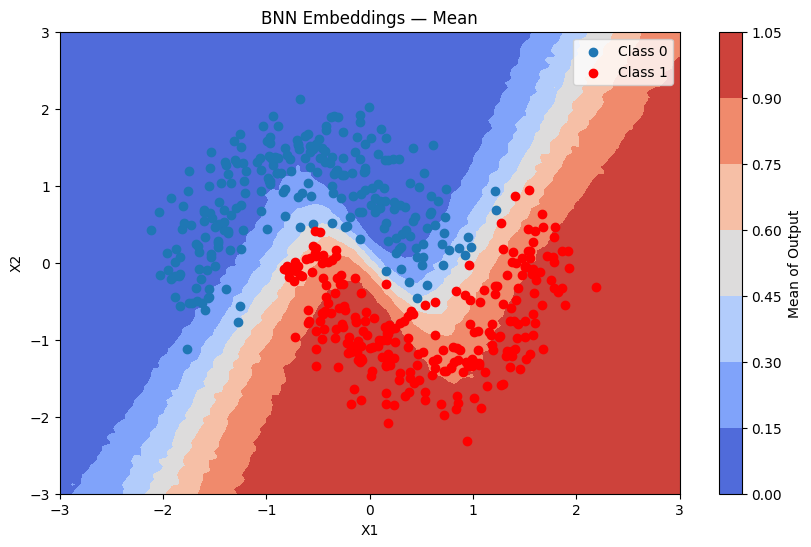

In [22]:
ctx_grid = np.column_stack([grid_2d, encode_region(grid_2d[:, 0])])

batch_predictions_emb_grid = [bnn_emb.sample_proba(ctx_grid, rng=rng) for _ in range(500)]
batch_proba_emb_grid = np.array([[p[0] for p in preds] for preds in batch_predictions_emb_grid])

plot_map(batch_proba_emb_grid.mean(axis=0), grid, x_test, pred_emb, "Mean", "BNN Embeddings — Mean")

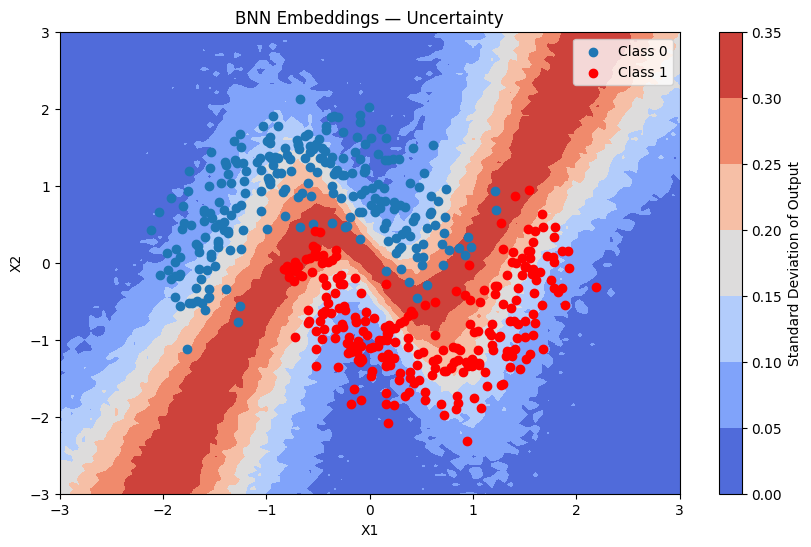

In [23]:
plot_map(batch_proba_emb_grid.std(axis=0), grid, x_test, pred_emb, "Standard Deviation", "BNN Embeddings — Uncertainty")

### Inspecting the Learned Embeddings

In [24]:
# Embedding for the first (and only) categorical feature — region (index 0 in the list)
emb_dist = bnn_emb.model_params.embedding_params.embeddings[0]

print("Learned embedding means (mu) for each 'region' category:")
for label, mu_row in zip(region_labels, emb_dist.mu):
    print(f"  {label:8s}: {[round(v, 3) for v in mu_row]}")

print("\nLearned embedding std-devs (sigma) for each 'region' category:")
for label, sigma_row in zip(region_labels, emb_dist.sigma):
    print(f"  {label:8s}: {[round(v, 3) for v in sigma_row]}")

Learned embedding means (mu) for each 'region' category:
  left    : [-0.102]
  center  : [-0.001]
  right   : [-0.177]

Learned embedding std-devs (sigma) for each 'region' category:
  left    : [0.552]
  center  : [0.402]
  right   : [0.577]
